In [13]:
def gaussian_2d(mu, Sigma, n, rng):
    S11 = Sigma[0, 0]
    S12 = Sigma[0, 1]
    S22 = Sigma[1, 1]

    x1 = gaussian(mu[0], np.sqrt(S11), n, rng)

    z = gaussian(0, 1, n, rng)
    cond_mean = mu[1] + (S12 / S11) * (x1 - mu[0])
    cond_var = S22 - S12 ** 2 / S11
    x2 = cond_mean + np.sqrt(cond_var) * z

    return np.column_stack((x1, x2))

In [14]:
rng = np.random.default_rng(42)
N = 10000

mu1 = np.array([0.0, 0.0])
mu2 = np.array([4.0, 4.0])
mu3 = np.array([0.0, 6.0])

# simplest case first: sigma^2 I, same for all classes
Sigma1 = np.array([[2.0, 0.0], [0.0, 2.0]])
Sigma2 = np.array([[2.0, 0.0], [0.0, 2.0]])
Sigma3 = np.array([[2.0, 0.0], [0.0, 2.0]])

X1 = gaussian_2d(mu1, Sigma1, N, rng)
X2 = gaussian_2d(mu2, Sigma2, N, rng)
X3 = gaussian_2d(mu3, Sigma3, N, rng)

print(X1.shape, X2.shape, X3.shape)

(10000, 2) (10000, 2) (10000, 2)


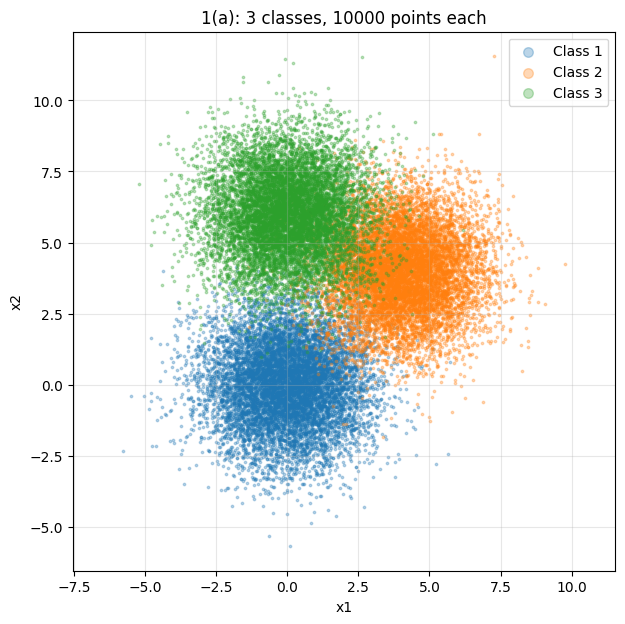

In [15]:
plt.figure(figsize=(7, 7))
plt.scatter(X1[:, 0], X1[:, 1], s=3, alpha=0.3, label="Class 1")
plt.scatter(X2[:, 0], X2[:, 1], s=3, alpha=0.3, label="Class 2")
plt.scatter(X3[:, 0], X3[:, 1], s=3, alpha=0.3, label="Class 3")
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("1(a): 3 classes, 10000 points each")
plt.axis("equal"); plt.grid(alpha=0.3); plt.legend(markerscale=4)
plt.show()

In [16]:
# the three covariance types

1)b
Sigma_iso  = np.array([[2.0, 0.0], [0.0, 2.0]])
Sigma_diag = np.array([[3.0, 0.0], [0.0, 1.0]])
Sigma_full = np.array([[3.0, 1.5], [1.5, 2.0]])

# (a) sigma^2 I, same for all 3 classes
A1 = gaussian_2d(mu1, Sigma_iso, N, rng)
A2 = gaussian_2d(mu2, Sigma_iso, N, rng)
A3 = gaussian_2d(mu3, Sigma_iso, N, rng)

# (b) diagonal, same for all 3 classes
B1 = gaussian_2d(mu1, Sigma_diag, N, rng)
B2 = gaussian_2d(mu2, Sigma_diag, N, rng)
B3 = gaussian_2d(mu3, Sigma_diag, N, rng)

# (c) full, same for all 3 classes
C1 = gaussian_2d(mu1, Sigma_full, N, rng)
C2 = gaussian_2d(mu2, Sigma_full, N, rng)
C3 = gaussian_2d(mu3, Sigma_full, N, rng)

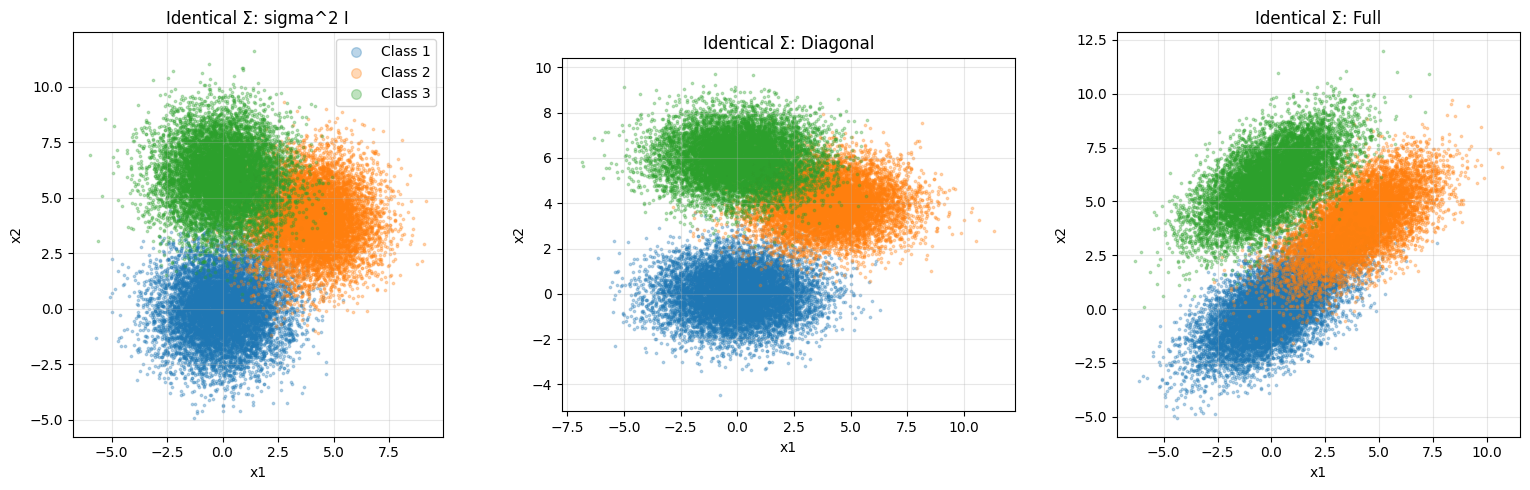

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sets = [("sigma^2 I", A1, A2, A3),
        ("Diagonal",  B1, B2, B3),
        ("Full",      C1, C2, C3)]

for ax, (title, P1, P2, P3) in zip(axes, sets):
    ax.scatter(P1[:, 0], P1[:, 1], s=3, alpha=0.3, label="Class 1")
    ax.scatter(P2[:, 0], P2[:, 1], s=3, alpha=0.3, label="Class 2")
    ax.scatter(P3[:, 0], P3[:, 1], s=3, alpha=0.3, label="Class 3")
    ax.set_title(f"Identical Σ: {title}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

axes[0].legend(markerscale=4)
plt.tight_layout()
plt.show()

In [21]:
# (a) sigma^2 I, different per class

 # 1 c ) 
Sigma1_iso = np.array([[1.0, 0.0], [0.0, 1.0]])
Sigma2_iso = np.array([[3.0, 0.0], [0.0, 3.0]])
Sigma3_iso = np.array([[2.0, 0.0], [0.0, 2.0]])

D1 = gaussian_2d(mu1, Sigma1_iso, N, rng)
D2 = gaussian_2d(mu2, Sigma2_iso, N, rng)
D3 = gaussian_2d(mu3, Sigma3_iso, N, rng)

# (b) diagonal, different per class
Sigma1_diag = np.array([[1.0, 0.0], [0.0, 3.0]])
Sigma2_diag = np.array([[4.0, 0.0], [0.0, 1.0]])
Sigma3_diag = np.array([[2.0, 0.0], [0.0, 2.0]])

E1 = gaussian_2d(mu1, Sigma1_diag, N, rng)
E2 = gaussian_2d(mu2, Sigma2_diag, N, rng)
E3 = gaussian_2d(mu3, Sigma3_diag, N, rng)

# (c) full, different per class
Sigma1_full = np.array([[2.0, 1.2], [1.2, 2.0]])
Sigma2_full = np.array([[3.0, -1.5], [-1.5, 2.0]])
Sigma3_full = np.array([[1.5, 0.5], [0.5, 3.0]])

F1 = gaussian_2d(mu1, Sigma1_full, N, rng)
F2 = gaussian_2d(mu2, Sigma2_full, N, rng)
F3 = gaussian_2d(mu3, Sigma3_full, N, rng)

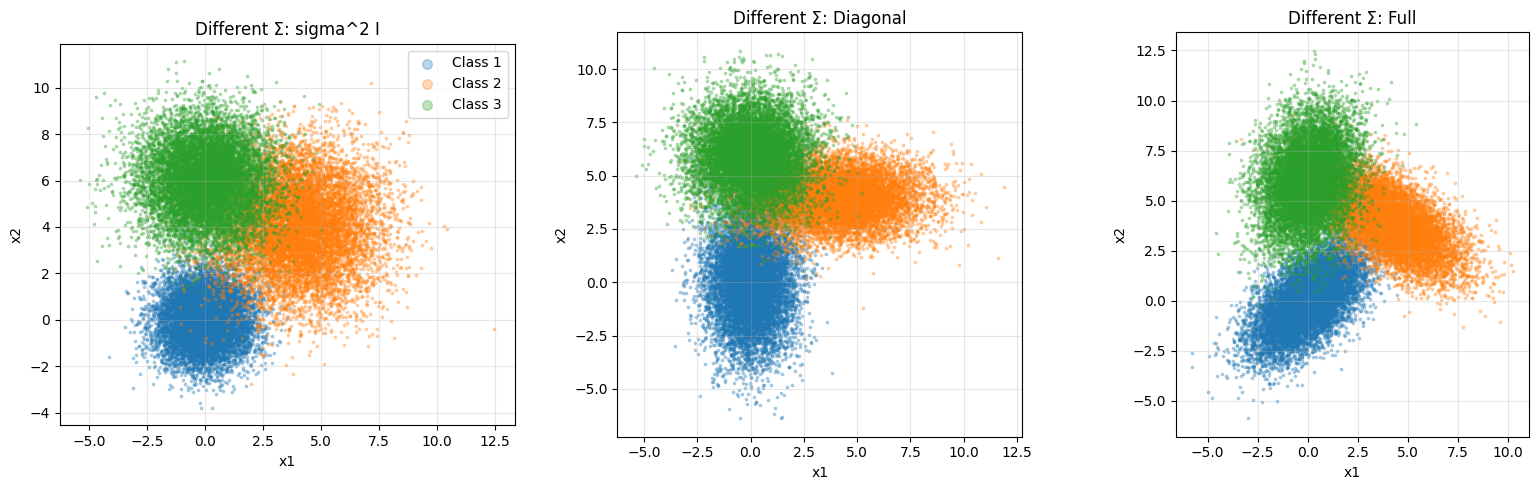

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sets = [("sigma^2 I", D1, D2, D3),
        ("Diagonal",  E1, E2, E3),
        ("Full",      F1, F2, F3)]

for ax, (title, P1, P2, P3) in zip(axes, sets):
    ax.scatter(P1[:, 0], P1[:, 1], s=3, alpha=0.3, label="Class 1")
    ax.scatter(P2[:, 0], P2[:, 1], s=3, alpha=0.3, label="Class 2")
    ax.scatter(P3[:, 0], P3[:, 1], s=3, alpha=0.3, label="Class 3")
    ax.set_title(f"Different Σ: {title}")
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal"); ax.grid(alpha=0.3)

axes[0].legend(markerscale=4)
plt.tight_layout()
plt.show()

In [20]:
# split: 80% train (8000), 20% test (2000) per class

# 1d)

F1_train, F1_test = F1[:8000], F1[8000:]
F2_train, F2_test = F2[:8000], F2[8000:]
F3_train, F3_test = F3[:8000], F3[8000:]

print(F1_train.shape, F1_test.shape)

(8000, 2) (2000, 2)


In [23]:
n = len(F1_train)

# mean: (1/n) * sum of x
mu1_hat = np.array([np.sum(F1_train[:, 0]) / n,
                    np.sum(F1_train[:, 1]) / n])

# offsets from the mean
d1 = F1_train[:, 0] - mu1_hat[0]
d2 = F1_train[:, 1] - mu1_hat[1]

# covariance: (1/n) * sum of (x-mu)(x-mu)^T, one entry at a time
S11 = np.sum(d1 * d1) / n
S12 = np.sum(d1 * d2) / n
S22 = np.sum(d2 * d2) / n
Sigma1_hat = np.array([[S11, S12],
                       [S12, S22]])

print("true mu   :", mu1)
print("est  mu   :", mu1_hat)
print("true Sigma:\n", Sigma1_full)
print("est  Sigma:\n", Sigma1_hat)

true mu   : [0. 0.]
est  mu   : [-0.01616454  0.01762131]
true Sigma:
 [[2.  1.2]
 [1.2 2. ]]
est  Sigma:
 [[1.96512662 1.15375624]
 [1.15375624 1.97418758]]


In [24]:
def mle(X):
    n = len(X)
    mu_hat = np.array([np.sum(X[:, 0]) / n,
                       np.sum(X[:, 1]) / n])
    d1 = X[:, 0] - mu_hat[0]
    d2 = X[:, 1] - mu_hat[1]
    S11 = np.sum(d1 * d1) / n
    S12 = np.sum(d1 * d2) / n
    S22 = np.sum(d2 * d2) / n
    return mu_hat, np.array([[S11, S12], [S12, S22]])

mu2_hat, Sigma2_hat = mle(F2_train)
mu3_hat, Sigma3_hat = mle(F3_train)

for i, (m, S) in enumerate([(mu1_hat, Sigma1_hat),
                            (mu2_hat, Sigma2_hat),
                            (mu3_hat, Sigma3_hat)], start=1):
    print(f"Class {i}  mu_hat = {np.round(m, 3)}")
    print(np.round(S, 3))

Class 1  mu_hat = [-0.016  0.018]
[[1.965 1.154]
 [1.154 1.974]]
Class 2  mu_hat = [3.99  4.001]
[[ 2.944 -1.447]
 [-1.447  1.96 ]]
Class 3  mu_hat = [0.016 6.021]
[[1.485 0.506]
 [0.506 3.009]]


In [25]:
#)1d

datasets = {
    "Same, sigma^2 I": [A1, A2, A3],
    "Same, diagonal":  [B1, B2, B3],
    "Same, full":      [C1, C2, C3],
    "Diff, sigma^2 I": [D1, D2, D3],
    "Diff, diagonal":  [E1, E2, E3],
    "Diff, full":      [F1, F2, F3],
}

train, test, params = {}, {}, {}

for name, classes in datasets.items():
    train[name]  = [X[:8000] for X in classes]
    test[name]   = [X[8000:] for X in classes]
    params[name] = [mle(X) for X in train[name]]

    print("\n" + name)
    for i in range(3):
        mu_hat, Sigma_hat = params[name][i]
        print(f"  Class {i+1}  mu_hat = {np.round(mu_hat, 3)}")
        print(np.round(Sigma_hat, 3))


Same, sigma^2 I
  Class 1  mu_hat = [ 0.006 -0.004]
[[2.086 0.063]
 [0.063 1.966]]
  Class 2  mu_hat = [3.996 4.021]
[[2.041 0.029]
 [0.029 2.002]]
  Class 3  mu_hat = [-0.036  6.002]
[[ 2.023 -0.022]
 [-0.022  1.938]]

Same, diagonal
  Class 1  mu_hat = [ 0.007 -0.013]
[[2.956 0.021]
 [0.021 1.011]]
  Class 2  mu_hat = [3.98  4.004]
[[ 2.997 -0.015]
 [-0.015  1.011]]
  Class 3  mu_hat = [0.039 6.009]
[[ 3.038 -0.019]
 [-0.019  1.008]]

Same, full
  Class 1  mu_hat = [ 0.008 -0.008]
[[2.974 1.439]
 [1.439 1.938]]
  Class 2  mu_hat = [4.016 4.018]
[[2.936 1.465]
 [1.465 2.013]]
  Class 3  mu_hat = [3.000e-03 5.972e+00]
[[2.978 1.487]
 [1.487 2.013]]

Diff, sigma^2 I
  Class 1  mu_hat = [-0.011  0.011]
[[1.022 0.028]
 [0.028 1.023]]
  Class 2  mu_hat = [3.989 4.006]
[[ 3.036 -0.013]
 [-0.013  3.001]]
  Class 3  mu_hat = [5.000e-03 6.013e+00]
[[ 1.991 -0.015]
 [-0.015  2.04 ]]

Diff, diagonal
  Class 1  mu_hat = [-0.013 -0.022]
[[ 0.999 -0.037]
 [-0.037  2.958]]
  Class 2  mu_hat = [3.95

In [26]:
def g(X, mu_hat, Sigma_hat):
    a = Sigma_hat[0, 0]
    b = Sigma_hat[0, 1]
    d = Sigma_hat[1, 1]

    det = a * d - b * b
    inv11 = d / det
    inv12 = -b / det
    inv22 = a / det

    u = X[:, 0] - mu_hat[0]
    v = X[:, 1] - mu_hat[1]

    maha2 = inv11 * u * u + 2 * inv12 * u * v + inv22 * v * v

    return -0.5 * maha2 - 0.5 * np.log(det)

In [27]:
predictions = {}   # predictions[name] = (X_test_all, y_true, y_pred)

for name in datasets:
    # stack the three test sets into one, with true labels 0,1,2
    X_test = np.vstack(test[name])
    y_true = np.concatenate([np.full(2000, 0),
                             np.full(2000, 1),
                             np.full(2000, 2)])

    # score every test point under each class model
    g1 = g(X_test, *params[name][0])
    g2 = g(X_test, *params[name][1])
    g3 = g(X_test, *params[name][2])

    # pick the class with the largest g
    scores = np.column_stack((g1, g2, g3))
    y_pred = np.argmax(scores, axis=1)

    predictions[name] = (X_test, y_true, y_pred)

    correct = np.sum(y_pred == y_true)
    print(f"{name:18s} correct: {correct} / {len(y_true)}")

Same, sigma^2 I    correct: 5640 / 6000
Same, diagonal     correct: 5698 / 6000
Same, full         correct: 5659 / 6000
Diff, sigma^2 I    correct: 5615 / 6000
Diff, diagonal     correct: 5558 / 6000
Diff, full         correct: 5647 / 6000


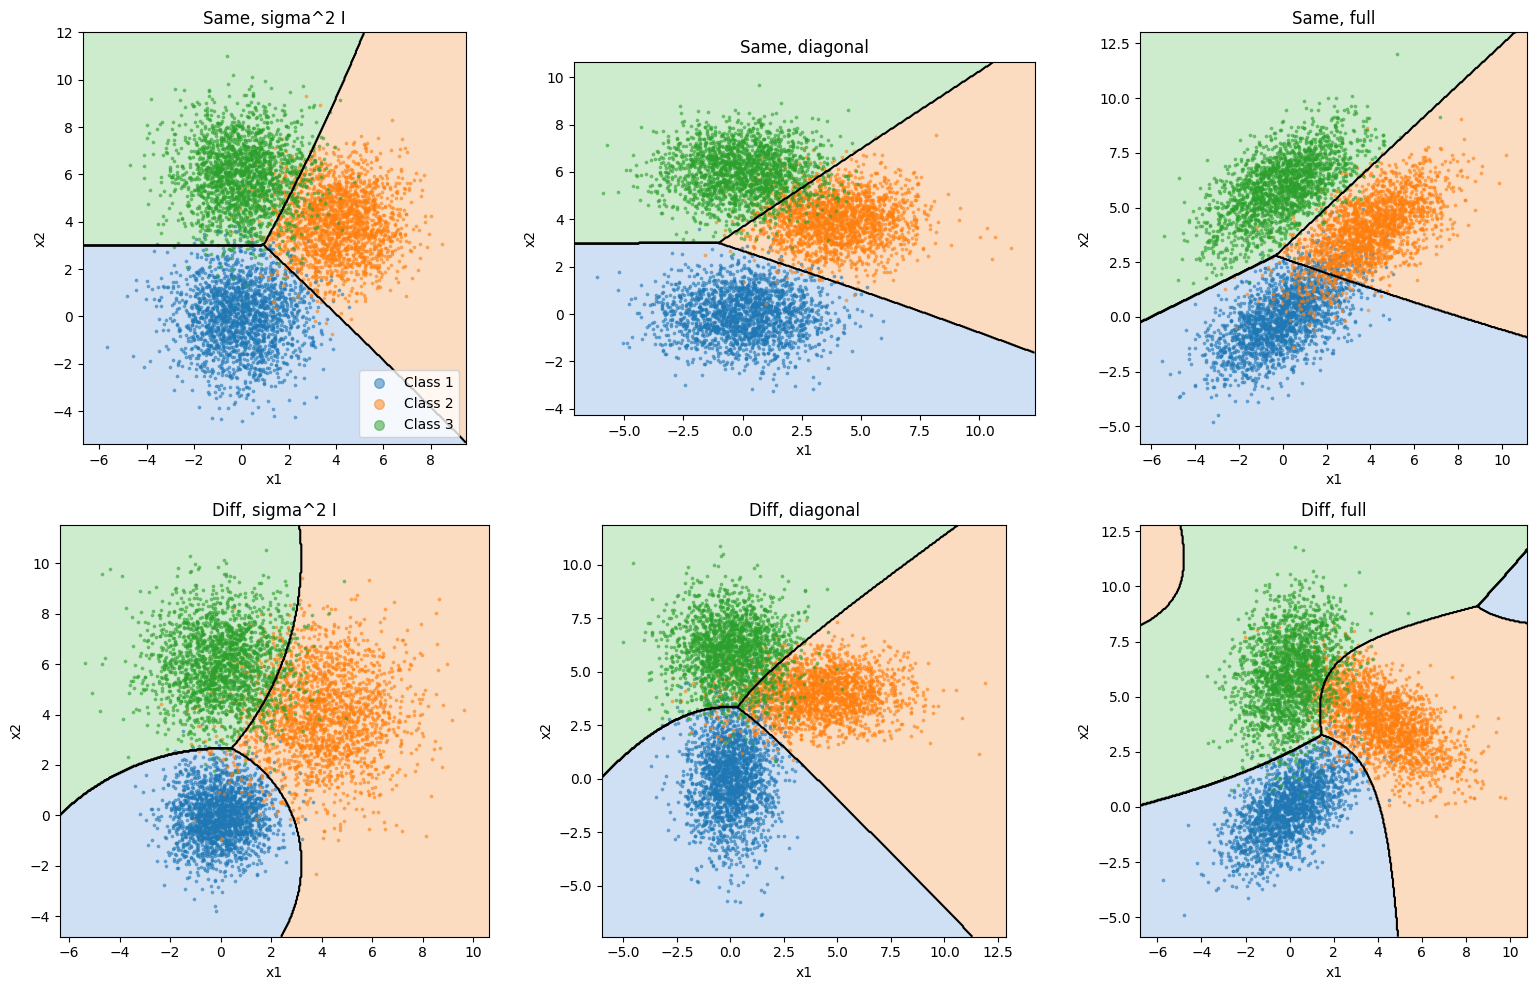

In [28]:
# 1 f 

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
region_colors = plt.matplotlib.colors.ListedColormap(["#cfe0f5", "#fbdcc0", "#cdeccd"])
point_colors = ["tab:blue", "tab:orange", "tab:green"]

for ax, name in zip(axes.ravel(), datasets):
    X_test, y_true, y_pred = predictions[name]

    # grid covering the test data
    gx = np.linspace(X_test[:, 0].min() - 1, X_test[:, 0].max() + 1, 400)
    gy = np.linspace(X_test[:, 1].min() - 1, X_test[:, 1].max() + 1, 400)
    GX, GY = np.meshgrid(gx, gy)
    grid = np.column_stack((GX.ravel(), GY.ravel()))

    # classify every grid point with the same rule
    s1 = g(grid, *params[name][0])
    s2 = g(grid, *params[name][1])
    s3 = g(grid, *params[name][2])
    Z = np.argmax(np.column_stack((s1, s2, s3)), axis=1).reshape(GX.shape)

    # decision regions and boundaries
    ax.contourf(GX, GY, Z, levels=[-0.5, 0.5, 1.5, 2.5], cmap=region_colors)
    ax.contour(GX, GY, Z, levels=[0.5, 1.5], colors="black", linewidths=1.5)

    # test data on top
    for c in range(3):
        pts = X_test[y_true == c]
        ax.scatter(pts[:, 0], pts[:, 1], s=3, alpha=0.5,
                   color=point_colors[c], label=f"Class {c+1}")

    ax.set_title(name)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")
    ax.set_aspect("equal")

axes[0, 0].legend(markerscale=4, loc="lower right")
plt.tight_layout()
plt.show()

In [30]:
# 1 g

for name in datasets:
    X_test, y_true, y_pred = predictions[name]

    cm = np.zeros((3, 3), dtype=int)
    for i in range(3):
        for j in range(3):
            cm[i, j] = np.sum((y_true == i) & (y_pred == j))

    print("\n" + name)
    print("           Pred 1   Pred 2   Pred 3")
    for i in range(3):
        print(f"True {i+1}   {cm[i,0]:7d}  {cm[i,1]:7d}  {cm[i,2]:7d}")


Same, sigma^2 I
           Pred 1   Pred 2   Pred 3
True 1      1935       34       31
True 2        28     1862      110
True 3        31      126     1843

Same, diagonal
           Pred 1   Pred 2   Pred 3
True 1      1977       22        1
True 2        22     1849      129
True 3         1      127     1872

Same, full
           Pred 1   Pred 2   Pred 3
True 1      1855      143        2
True 2       137     1827       36
True 3         1       22     1977

Diff, sigma^2 I
           Pred 1   Pred 2   Pred 3
True 1      1974       18        8
True 2        54     1792      154
True 3        10      141     1849

Diff, diagonal
           Pred 1   Pred 2   Pred 3
True 1      1906       45       49
True 2        42     1825      133
True 3        31      142     1827

Diff, full
           Pred 1   Pred 2   Pred 3
True 1      1949       39       12
True 2        24     1829      147
True 3        38       93     1869
